# 01 — Descriptive Statistics
**References:** Freedman, Pisani & Purves (2007) · Tukey (1977) *EDA* · Cleveland (1993)

## Narrative thread
```
Data types -> Center -> Spread -> Shape -> Relationships -> Visualization
```

## Why descriptive statistics?
Before modeling, you must *understand* your data. Descriptive statistics summarize the
distribution of a variable — its typical value, its spread, and its shape.
A model built on misunderstood data is wrong by construction.

---

## Data types

| Type | Examples | Valid summaries |
|---|---|---|
| **Nominal** | Gender, country | Mode, frequency |
| **Ordinal** | Rating 1-5, education level | Median, percentiles |
| **Interval** | Temperature (°C), year | Mean, SD (no meaningful ratio) |
| **Ratio** | Income, height, age | All — including ratios and geometric mean |

---

## Measures of center

| Measure | Formula | Resistant to outliers? |
|---|---|---|
| Mean | $\bar{x} = \frac{1}{n}\sum x_i$ | No |
| Median | Middle value when sorted | Yes |
| Mode | Most frequent value | Yes |
| Trimmed mean | Mean after dropping top/bottom $k\%$ | Partially |

## Measures of spread

| Measure | Formula | Notes |
|---|---|---|
| Variance | $s^2 = \frac{1}{n-1}\sum(x_i-\bar{x})^2$ | Same units squared |
| Std deviation | $s = \sqrt{s^2}$ | Same units as $x$ |
| IQR | $Q_3 - Q_1$ | Resistant; used in boxplots |
| MAD | $\text{median}|x_i - \text{median}|$ | Most resistant |
| CV | $s/\bar{x}$ | Dimensionless; compare spread across scales |

## Shape

- **Skewness:** $\gamma_1 = \frac{1}{n}\sum\left(\frac{x_i-\bar{x}}{s}\right)^3$ — positive = right tail, negative = left tail
- **Kurtosis:** $\gamma_2 = \frac{1}{n}\sum\left(\frac{x_i-\bar{x}}{s}\right)^4 - 3$ — excess relative to normal (0 = normal, >0 = heavy tails)

**Rule of thumb:** if $|\text{skew}| > 1$, consider log-transforming the variable.

In [5]:
from pathlib import Path
import os

# Busca la raíz del proyecto subiendo carpetas hasta encontrar .git
def find_project_root(start_path=None):
    start_path = Path(start_path or Path.cwd()).resolve()
    
    for path in [start_path, *start_path.parents]:
        if (path / ".git").exists():
            return path
    
    raise FileNotFoundError("No se encontró la raíz del proyecto con .git")

PROJECT_ROOT = find_project_root()
os.chdir(PROJECT_ROOT)

PROJECT_ROOT

PosixPath('/home/gabper12/Projects/learning_courses')

In [6]:
# import os
# os.chdir('/Volumes/SSD_Gabo/proyectos/growth-analytics')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams.update({
    'figure.dpi': 130, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.color': '#e8e8e8', 'axes.axisbelow': True,
    'axes.titlesize': 11, 'axes.titleweight': 'bold', 'legend.frameon': False,
    'font.family':'sans-serif', 'font.size': 10, 'xtick.labelsize': 9, 'ytick.labelsize': 9
})
np.random.seed(42)

=== Measures of center: income ===
  Mean:               81,614
  Median:             50,378
  Trimmed mean:       59,937  (5% trim)

=== Measures of spread ===
  Std deviation:      144,791
  IQR:                 38,429
  CV:                   1.774

=== Shape ===
  Skewness: 9.416   (>1 -> consider log transform)
  Kurtosis: 125.448  (excess; 0 = normal)


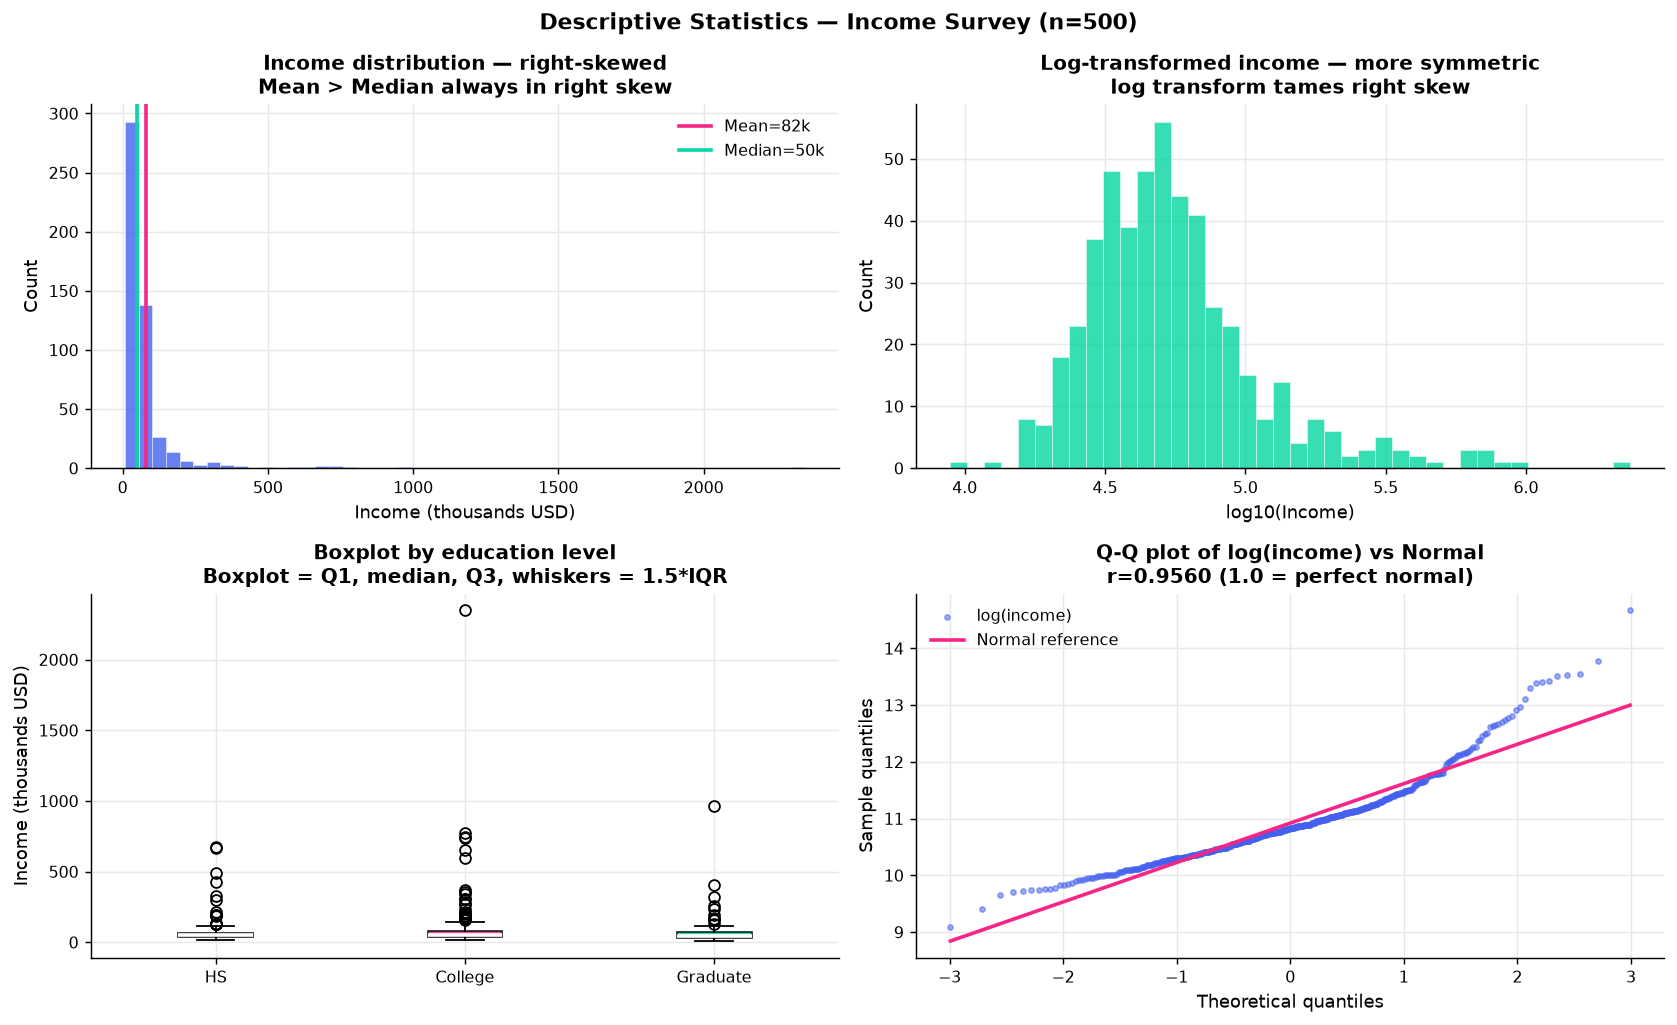

In [7]:
# ── Dataset: income survey (right-skewed, realistic) ─────────────────────
n = 500
income = np.concatenate([
    np.random.lognormal(mean=np.log(45000), sigma=0.5, size=430),
    np.random.lognormal(mean=np.log(200000), sigma=0.8, size=70),
])
age    = np.random.normal(38, 12, n).clip(18, 75)
df = pd.DataFrame({'income': income, 'age': age,
                   'education': np.random.choice(['HS','College','Graduate'], n, p=[0.35,0.45,0.20])})

# ── Measures of center ───────────────────────────────────────────────────
print('=== Measures of center: income ===')
print(f'  Mean:         {df.income.mean():>12,.0f}')
print(f'  Median:       {df.income.median():>12,.0f}')
print(f'  Trimmed mean: {stats.trim_mean(df.income, 0.05):>12,.0f}  (5% trim)')

print()
print('=== Measures of spread ===')
print(f'  Std deviation: {df.income.std():>12,.0f}')
print(f'  IQR:           {df.income.quantile(0.75)-df.income.quantile(0.25):>12,.0f}')
print(f'  CV:            {df.income.std()/df.income.mean():>12.3f}')

print()
print('=== Shape ===')
print(f'  Skewness: {stats.skew(df.income):.3f}   (>1 -> consider log transform)')
print(f'  Kurtosis: {stats.kurtosis(df.income):.3f}  (excess; 0 = normal)')

# ── 4-panel visualization ────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

# Histogram raw
ax = axes[0,0]
ax.hist(df.income/1000, bins=50, color='#4361ee', alpha=0.8, edgecolor='white', linewidth=0.3)
ax.axvline(df.income.mean()/1000,   color='#f72585', lw=2, label=f'Mean={df.income.mean()/1000:.0f}k')
ax.axvline(df.income.median()/1000, color='#06d6a0', lw=2, label=f'Median={df.income.median()/1000:.0f}k')
ax.set_xlabel('Income (thousands USD)'); ax.set_ylabel('Count')
ax.set_title('Income distribution — right-skewed\nMean > Median always in right skew')
ax.legend(fontsize=9)

# Histogram log
ax = axes[0,1]
ax.hist(np.log10(df.income), bins=40, color='#06d6a0', alpha=0.8, edgecolor='white', linewidth=0.3)
ax.set_xlabel('log10(Income)'); ax.set_ylabel('Count')
ax.set_title('Log-transformed income — more symmetric\nlog transform tames right skew')

# Boxplot by education
ax = axes[1,0]
groups = [df[df.education==e]['income']/1000 for e in ['HS','College','Graduate']]
bp = ax.boxplot(groups, tick_labels=['HS','College','Graduate'], patch_artist=True,
                medianprops=dict(color='white', linewidth=2))
colors = ['#4361ee','#f72585','#06d6a0']
for patch, c in zip(bp['boxes'], colors):
    patch.set_facecolor(c); patch.set_alpha(0.8)
ax.set_ylabel('Income (thousands USD)')
ax.set_title('Boxplot by education level\nBoxplot = Q1, median, Q3, whiskers = 1.5*IQR')

# QQ plot
ax = axes[1,1]
probplot_result = stats.probplot(np.log(df.income), plot=None)
osm, osr = probplot_result[0]
slope, intercept, r = probplot_result[1]
ax.scatter(osm, osr, s=8, alpha=0.5, color='#4361ee', label='log(income)')
ax.plot(osm, slope*np.array(osm)+intercept, color='#f72585', lw=2, label='Normal reference')
ax.set_xlabel('Theoretical quantiles'); ax.set_ylabel('Sample quantiles')
ax.set_title(f'Q-Q plot of log(income) vs Normal\nr={r:.4f} (1.0 = perfect normal)')
ax.legend(fontsize=9)

plt.suptitle('Descriptive Statistics — Income Survey (n=500)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## Five-number summary and outlier detection

The **five-number summary** (min, Q1, median, Q3, max) describes the full distribution
without assuming any shape.

**Tukey's fence:** points beyond $Q_1 - 1.5\,\text{IQR}$ or $Q_3 + 1.5\,\text{IQR}$ are
flagged as potential outliers. This is the rule used in boxplots.
Use $3\,\text{IQR}$ for "extreme" outliers.

**Z-score rule:** $|z_i| = |x_i - \bar{x}|/s > 3$ — only valid when distribution is roughly normal.
Do not use on skewed data (the mean and SD are both distorted by the same outliers you're trying to find).

Five-number summary:
count        500.0
mean       81614.0
std       144791.0
min         8900.0
25%        34466.0
50%        50378.0
75%        72894.0
max      2348241.0
Name: income, dtype: float64

Tukey fences: [-23,178, 130,537]
Outliers (Tukey 1.5*IQR): 52 (10.4%)


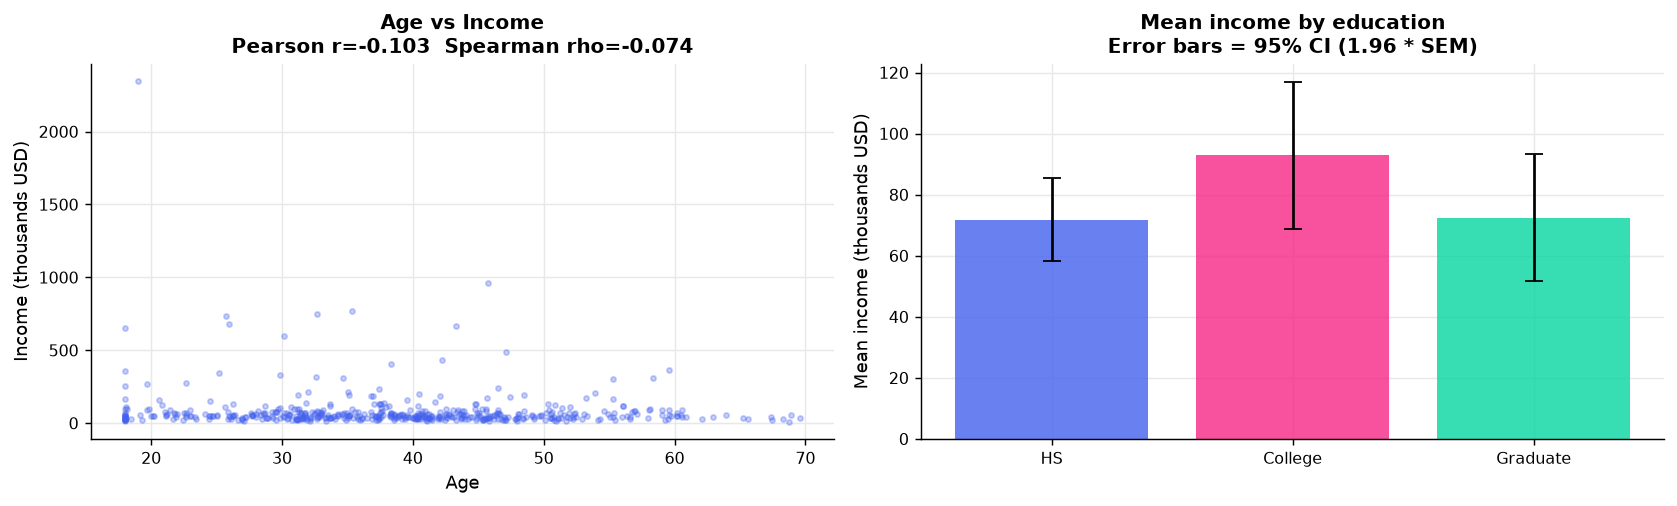

In [8]:
# ── Five-number summary ──────────────────────────────────────────────────
print('Five-number summary:')
print(df.income.describe(percentiles=[.25,.5,.75]).round(0))

q1, q3 = df.income.quantile([0.25, 0.75])
iqr = q3 - q1
lo_fence, hi_fence = q1 - 1.5*iqr, q3 + 1.5*iqr

outliers = df[(df.income < lo_fence) | (df.income > hi_fence)]
print(f'\nTukey fences: [{lo_fence:,.0f}, {hi_fence:,.0f}]')
print(f'Outliers (Tukey 1.5*IQR): {len(outliers)} ({len(outliers)/n*100:.1f}%)')

# ── Relationship: income vs age (scatter + correlation) ───────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.scatter(df.age, df.income/1000, s=8, alpha=0.3, color='#4361ee')
r_pearson  = stats.pearsonr(df.age, df.income)[0]
r_spearman = stats.spearmanr(df.age, df.income)[0]
ax.set_xlabel('Age'); ax.set_ylabel('Income (thousands USD)')
ax.set_title(f'Age vs Income\nPearson r={r_pearson:.3f}  Spearman rho={r_spearman:.3f}')

ax2 = axes[1]
edu_order = ['HS', 'College', 'Graduate']
means = df.groupby('education')['income'].mean().reindex(edu_order)/1000
sems  = df.groupby('education')['income'].sem().reindex(edu_order)/1000
ax2.bar(edu_order, means, yerr=sems*1.96, color=['#4361ee','#f72585','#06d6a0'],
        alpha=0.8, capsize=5)
ax2.set_ylabel('Mean income (thousands USD)')
ax2.set_title('Mean income by education\nError bars = 95% CI (1.96 * SEM)')

plt.tight_layout()
plt.show()